<font size = 10>\
    Projet 4 - Build a scoring model

Import usefull package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from sklearn.datasets import make_classification

from sklearn.dummy import DummyClassifier

from sklearn.utils import resample

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA

from sklearn.kernel_ridge import KernelRidge

from sklearn.pipeline import make_pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset

## Working with the Loan appplication data set

### Data

In [76]:
app_data = pd.read_csv('data/application_train.csv')
print('Training data shape: ', app_data.shape)

Training data shape:  (307511, 122)


### Kaggle Testing dataset

In [77]:
app_kaggle = pd.read_csv('data/application_test.csv')
print('Testing data shape: ', app_kaggle.shape)

Testing data shape:  (48744, 121)


# Exploratory Data Analysis

## Distribution of the target

In [17]:
app_data['TARGET'].value_counts()

0    282686
1     24825
Name: TARGET, dtype: int64

## Missing values

In [18]:
(app_data.isna().sum(axis = 0) / app_data.shape[0]).sort_values(ascending=False)[0:20]

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MEDI               0.593767
dtype: float64

## Feature types

In [19]:
app_data.dtypes.value_counts()

float64    65
int64      41
object     16
dtype: int64

### Encoding Categorical Variables

Encode with labelEncoder for 2 unique categories or use get_dumies

In [78]:
from sklearn.preprocessing import LabelEncoder


# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_data:
    if app_data[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_data[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_data[col])
            # Transform both training and testing data
            app_data[col] = le.transform(app_data[col])
            app_kaggle[col] = le.transform(app_kaggle[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [79]:
# one-hot encoding of categorical variables
app_data = pd.get_dummies(app_data)
app_kaggle = pd.get_dummies(app_kaggle)

print('Training Features shape: ', app_data.shape)
print('Testing Features shape: ', app_kaggle.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


In [80]:
train_labels = app_data['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_data, app_kaggle = app_data.align(app_kaggle, join = 'inner', axis = 1)

# Add the target back in
app_data['TARGET'] = train_labels

print('Training Features shape: ', app_data.shape)
print('Testing Features shape: ', app_kaggle.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


In [81]:
app_data.to_pickle('data/app_data_encode_categ')
app_kaggle.to_pickle('data/app_kaggle_encode_categ')

In [82]:
app_data.shape

(307511, 240)

In [83]:
app_kaggle.shape

(48744, 239)

### Outliers in numerical features

In [84]:
app_data=pd.read_pickle('data/app_data_encode_categ')
app_kaggle=pd.read_pickle('data/app_kaggle_encode_categ')

In [85]:
app_data.shape

(307511, 240)

In [86]:
app_kaggle.shape

(48744, 239)

Print the describe function on the numerical columns to check for outliers

In [24]:
app_num=app_data.select_dtypes(include=['float64','int64'])

In [25]:
def show_describe(i):
    return app_num.describe().iloc[:,(i-1)*10:i*10]

In [26]:
widgets.interact(show_describe, i=10)

interactive(children=(IntSlider(value=10, description='i', max=30, min=-10), Output()), _dom_classes=('widget-…

<function __main__.show_describe(i)>

In [87]:
suspected_outliers=['DAYS_EMPLOYED',
                    'OBS_30_CNT_SOCIAL_CIRCLE',
                    'DEF_30_CNT_SOCIAL_CIRCLE',
                    'OBS_60_CNT_SOCIAL_CIRCLE',
                    'DEF_60_CNT_SOCIAL_CIRCLE',
                    'AMT_REQ_CREDIT_BUREAU_HOUR',
                    'AMT_REQ_CREDIT_BUREAU_DAY',
                    'AMT_REQ_CREDIT_BUREAU_WEEK',
                    'AMT_REQ_CREDIT_BUREAU_MON',
                    'AMT_REQ_CREDIT_BUREAU_QRT',
                    'AMT_REQ_CREDIT_BUREAU_YEAR',
                    'HOUR_APPR_PROCESS_START'
                   ]

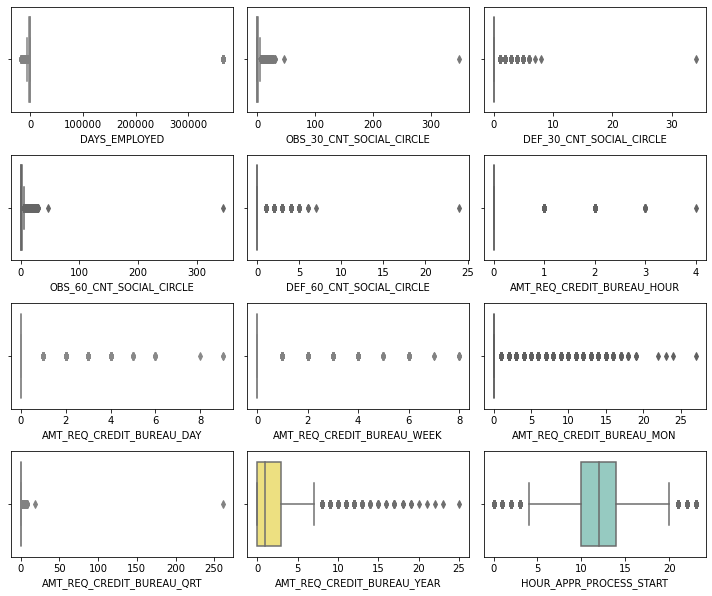

In [29]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

#### DAYS_EMPLOYED

In [88]:
app_data[app_data['DAYS_EMPLOYED']>200000].shape

(55374, 240)

<AxesSubplot:xlabel='DAYS_EMPLOYED'>

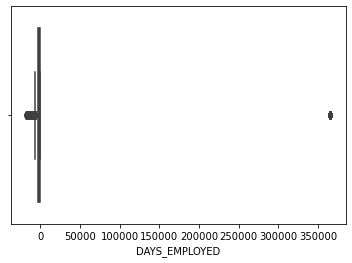

In [31]:
sns.boxplot(x=app_data['DAYS_EMPLOYED'])

In [97]:
# Create an anomalous flag column
app_data['DAYS_EMPLOYED_ANOM'] = app_data["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_data['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

# Apply the same steps to the test data
app_kaggle['DAYS_EMPLOYED_ANOM'] = app_kaggle["DAYS_EMPLOYED"] == 365243
app_kaggle["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)



#### Social circle features

In [98]:
app_data[app_data['OBS_30_CNT_SOCIAL_CIRCLE']>100].shape

(0, 241)

In [99]:
app_data.drop(index=app_data[app_data['OBS_30_CNT_SOCIAL_CIRCLE']>100].index,inplace=True)

<AxesSubplot:xlabel='DEF_30_CNT_SOCIAL_CIRCLE'>

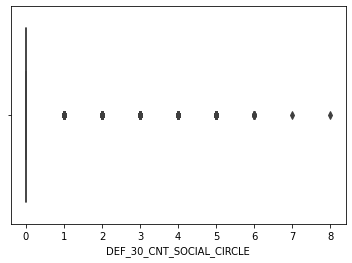

In [35]:
sns.boxplot(x=app_data['DEF_30_CNT_SOCIAL_CIRCLE'])

In [100]:
app_data[(app_data['DEF_30_CNT_SOCIAL_CIRCLE']>1.5) & (app_data['DEF_30_CNT_SOCIAL_CIRCLE']<2.5)].shape

(5323, 241)

In [101]:
app_data[(app_data['OBS_30_CNT_SOCIAL_CIRCLE']>15) & (app_data['OBS_30_CNT_SOCIAL_CIRCLE']<25)].shape

(418, 241)

<AxesSubplot:xlabel='DEF_60_CNT_SOCIAL_CIRCLE', ylabel='OBS_60_CNT_SOCIAL_CIRCLE'>

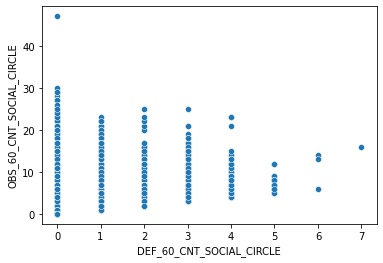

In [38]:
sns.scatterplot(x=app_data['DEF_60_CNT_SOCIAL_CIRCLE'],y=app_data['OBS_60_CNT_SOCIAL_CIRCLE'])

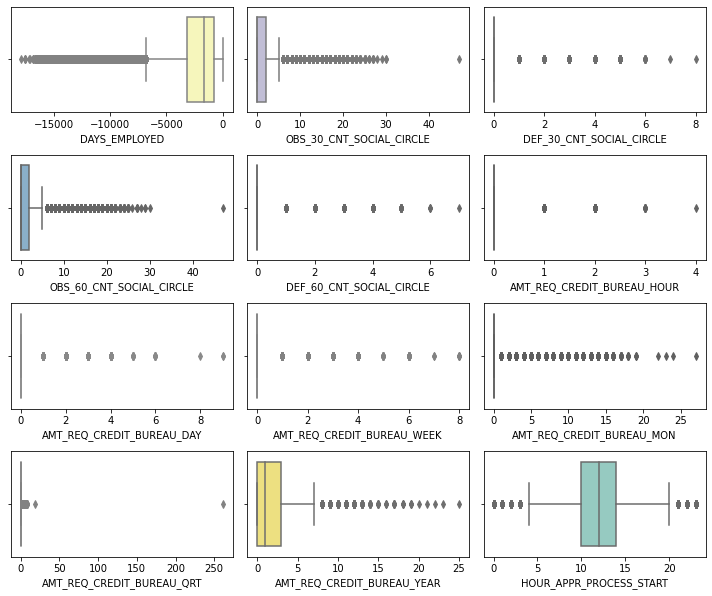

In [40]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

#### Amount of request features

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

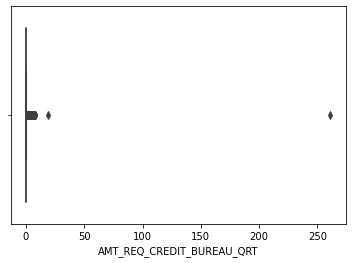

In [94]:
sns.boxplot(x=app_data['AMT_REQ_CREDIT_BUREAU_QRT'])

In [102]:
app_data[app_data['AMT_REQ_CREDIT_BUREAU_QRT']>15].shape

(0, 241)

In [103]:
app_data.drop(index=app_data[app_data['AMT_REQ_CREDIT_BUREAU_QRT']>15].index,inplace=True)

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

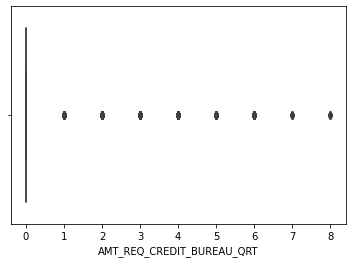

In [46]:
sns.boxplot(x=app_data['AMT_REQ_CREDIT_BUREAU_QRT'])

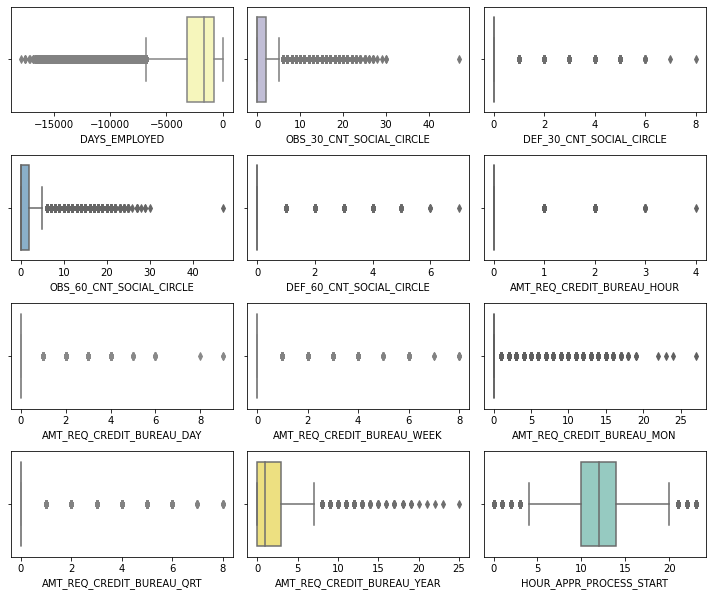

In [47]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

## SK_ID_CURR

In [315]:
app_data.index = app_data['SK_ID_CURR']
app_kaggle.index = app_kaggle['SK_ID_CURR']

In [317]:
app_data = app_data.drop(columns=['SK_ID_CURR'])
app_kaggle = app_kaggle.drop(columns=['SK_ID_CURR'])

## Saving datasets

In [320]:
app_data.to_pickle('data/app_data_outliers')
app_kaggle.to_pickle('data/app_kaggle_outliers')

## Correlations

In [2]:
app_data=pd.read_pickle('data/app_data_outliers')
app_kaggle=pd.read_pickle('data/app_kaggle_outliers')
print('app_data shape :', app_data.shape)
print('app_kaggle shape :',app_kaggle.shape)

app_data shape : (307508, 240)
app_kaggle shape : (48744, 239)


In [50]:
# correlation_matrix=app_data.corr()

In [51]:
# correlation_matrix.to_pickle('data/correlation_matrix')

In [52]:
correlation_matrix=pd.read_pickle('data/correlation_matrix')

In [53]:
np.fill_diagonal(correlation_matrix.values,0)

In [54]:
correlation_abs_matrix = correlation_matrix.abs()

In [55]:
corr_max_abs = pd.DataFrame(correlation_abs_matrix.idxmax(axis=0),columns=['feature'])

In [56]:
corr_max_abs['corr_coef']=correlation_abs_matrix.max(axis=0)

In [57]:
corr_max_abs.sort_values('corr_coef',ascending=False,inplace=True)

In [58]:
correlation_abs_matrix['TARGET'].sort_values(ascending=False).head(20)

EXT_SOURCE_3                                         0.178920
EXT_SOURCE_2                                         0.160448
EXT_SOURCE_1                                         0.155319
DAYS_BIRTH                                           0.078251
DAYS_EMPLOYED                                        0.074954
REGION_RATING_CLIENT_W_CITY                          0.060897
REGION_RATING_CLIENT                                 0.058903
NAME_INCOME_TYPE_Working                             0.057472
NAME_EDUCATION_TYPE_Higher education                 0.056585
DAYS_LAST_PHONE_CHANGE                               0.055208
CODE_GENDER_M                                        0.054723
CODE_GENDER_F                                        0.054714
DAYS_ID_PUBLISH                                      0.051451
REG_CITY_NOT_WORK_CITY                               0.051003
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049815
NAME_INCOME_TYPE_Pensioner                           0.046206
ORGANIZA

# Baseline

In [106]:
def show_score(y_test,y_pred_d_cls_prob,y_pred_d_cls):
    a=roc_auc_score(y_test,y_pred_d_cls_prob)
    b=f1_score(y_test,y_pred_d_cls)
    c=accuracy_score(y_test,y_pred_d_cls)
    d=precision_score(y_test,y_pred_d_cls)
    e=recall_score(y_test,y_pred_d_cls)
    print('ROC AUC   :',a)
    print('F1        :',b)
    print('Accuracy  :',c)
    print('Precision :',d)
    print('Recall    :',e)

## Test and Train split

In [3]:
X = app_data.drop( columns = ['TARGET'])
y = app_data['TARGET']
features = X.columns

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [324]:
X.shape

(307508, 239)

## Imputation of data

### Using SimpleImputer

In [4]:
simple_imputer = SimpleImputer(strategy = 'median')

## Standardization

In [5]:
scaler = StandardScaler()

In [326]:
pipeline_basic = make_pipeline(simple_imputer,scaler)
pipeline_basic.fit(X_train,y_train)
X_train_std = pipeline_basic.transform(X_train)
X_test_std = pipeline_basic.transform(X_test)

## Dummy classifier

In [327]:
cv = RepeatedStratifiedKFold(n_splits=10,n_repeats=3,random_state=1)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}

In [328]:
dummy_cls = make_pipeline(simple_imputer,scaler,DummyClassifier(strategy='stratified'))

In [329]:
scores = cross_validate(dummy_cls,X_train,y_train, scoring = scoring, cv=cv)
for key in scores.keys():
    print (f'Mean {key} : {scores[key].mean()}' )

KeyboardInterrupt: 

## Kaggle Submission

In [6]:
def kaggle_submit(estimator,data,output_name = 'submission_default.csv'):
    kaggle_pred = estimator.predict_proba(data)[:,1]
    kaggle_df = pd.DataFrame(data.index,columns=['SK_ID_CURR'])
    kaggle_df['TARGET'] = kaggle_pred
    kaggle_df.to_csv('data/'+output_name,index = False)

In [335]:
dummy_cls.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('dummyclassifier', DummyClassifier(strategy='stratified'))])

In [336]:
kaggle_submit(dummy_cls,app_kaggle,output_name='dummy_classifier.csv')

Kaggle gives 0.49

# Feature Selection

In [7]:
def features_importance_lg(estimator,features,n_features_plot = 40,plot = False):
    
    estimator_coef=pd.DataFrame(estimator.coef_.reshape(features.shape[0],),columns=['coeff'])
    estimator_coef['abs_coeff']=np.abs(estimator_coef['coeff'])
    estimator_coef['relative_importance']=estimator_coef['coeff'] / estimator_coef['abs_coeff'].sum()
    estimator_coef['abs_relative_importance']=estimator_coef['abs_coeff']/estimator_coef['abs_coeff'].sum()
    estimator_coef['sign']=np.sign(estimator_coef['coeff'])
    estimator_coef['feature']=features.values
    estimator_coef = estimator_coef.sort_values(by='abs_relative_importance',ascending=False)
    
    if plot == True:
        plt.figure(figsize=(10,10))
        sns.barplot(data=estimator_coef.head(n_features_plot),x ='relative_importance',y='feature',hue='sign',dodge=False)
        
    return estimator_coef

In [8]:
def features_importance_rdf(estimator,features,n_features_plot = 40, plot = False):
    
    estimator_coef=pd.DataFrame(estimator.feature_importances_.reshape(features.shape[0],),columns=['coeff'])
    estimator_coef['importance']=np.abs(estimator_coef['coeff'])
    estimator_coef['abs_relative_importance']=estimator_coef['importance']/estimator_coef['importance'].sum()
    estimator_coef['sign']=np.sign(estimator_coef['coeff'])
    estimator_coef['feature']=features.values
    estimator_coef = estimator_coef.sort_values(by='abs_relative_importance',ascending=False)
    
    if plot == True:
        plt.figure(figsize=(10,10))
        sns.barplot(data=estimator_coef.head(n_features_plot),x ='abs_relative_importance',y='feature',hue='sign',dodge=False)
        
    return estimator_coef

In [9]:
feature_importance={}

## Decision tree

In [14]:
tree = DecisionTreeClassifier(class_weight='balanced')

In [15]:
pipeline_tree = make_pipeline(simple_imputer,scaler,tree)

In [16]:
pipeline_tree.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(class_weight='balanced'))])

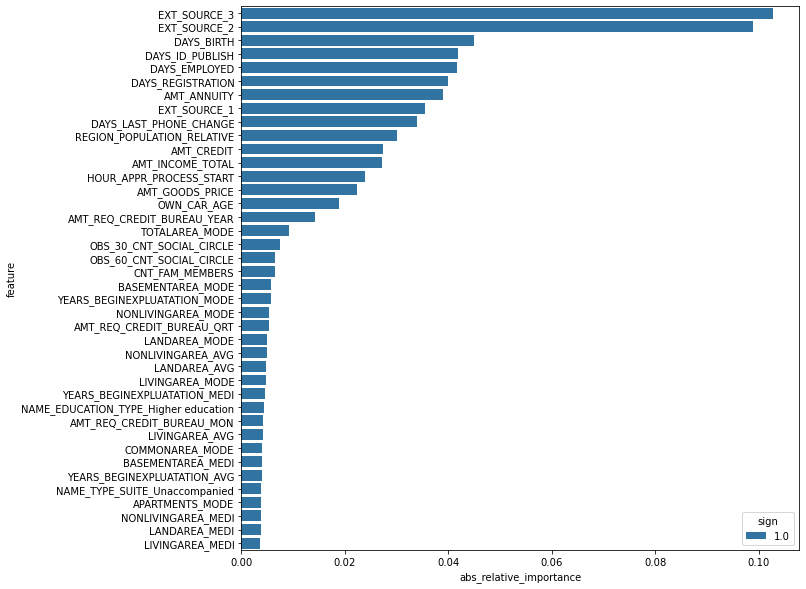

In [17]:
feature_importance['tree'] = features_importance_rdf(tree,features,plot=True)

## LDA

In [18]:
lda = LinearDiscriminantAnalysis()

In [19]:
pipeline_lda = make_pipeline(simple_imputer,scaler,lda)

In [20]:
pipeline_lda.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('lineardiscriminantanalysis', LinearDiscriminantAnalysis())])

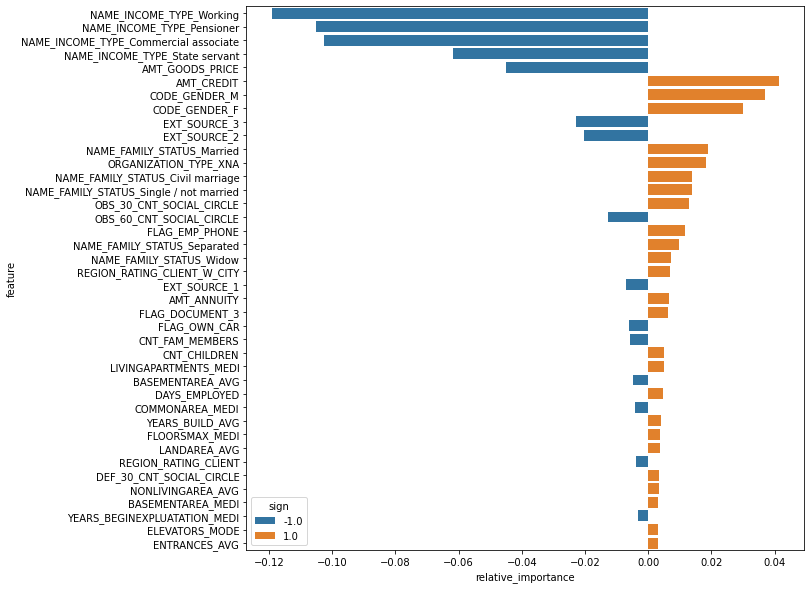

In [21]:
feature_importance['lda'] = features_importance_lg(lda,features,plot=True)

## Logistic regression

In [22]:
lr_bal = LogisticRegression(C = 0.01, max_iter = 200, class_weight = 'balanced')

In [23]:
pipeline_lr = make_pipeline(simple_imputer,scaler,lr_bal)

In [24]:
pipeline_lr.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=200))])

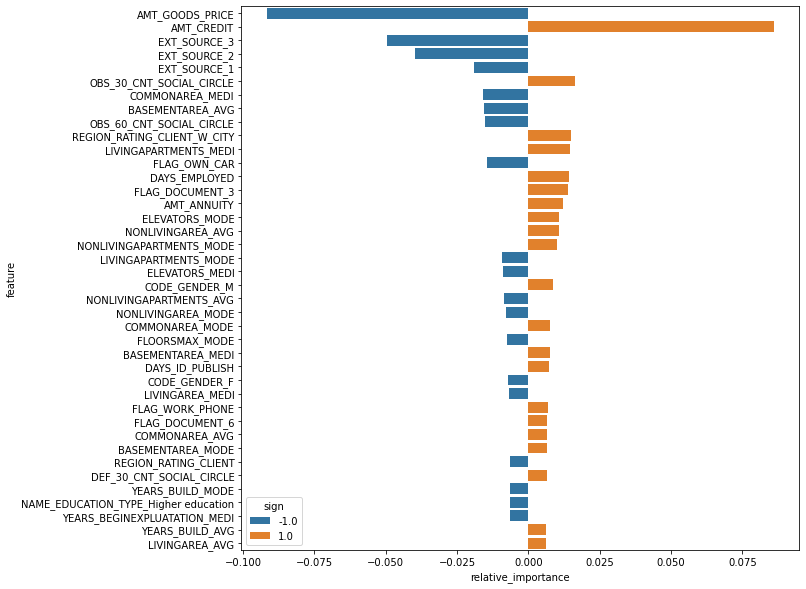

In [25]:
feature_importance['lg_bal'] = features_importance_lg(lr_bal,features,plot=True)

kaggle submission

In [26]:
kaggle_submit(pipeline_lr,app_kaggle,output_name='logistic_regression_balanced_option.csv')

Kaggle gives 0.73956

## Random forest

### Using Gini

In [27]:
rdf_gini = RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini')

In [28]:
pipeline_rdf_gini = make_pipeline(simple_imputer,scaler,rdf_gini)

In [29]:
pipeline_rdf_gini.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced'))])

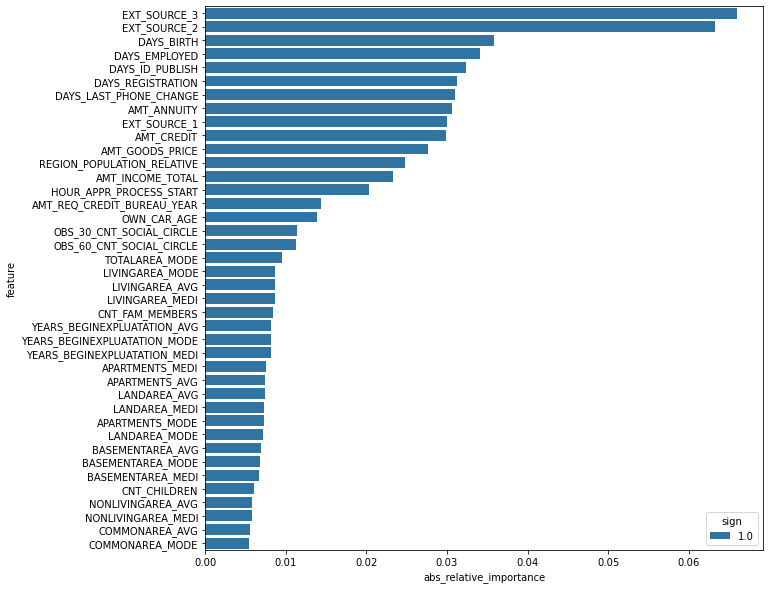

In [30]:
feature_importance['rdf_gini'] = features_importance_rdf(rdf_gini,features,plot = True)

### Using entropy

In [31]:
rdf_entropy = RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='entropy')

In [32]:
pipeline_rdf_entropy = make_pipeline(simple_imputer,scaler,rdf_entropy)

In [33]:
pipeline_rdf_entropy.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy'))])

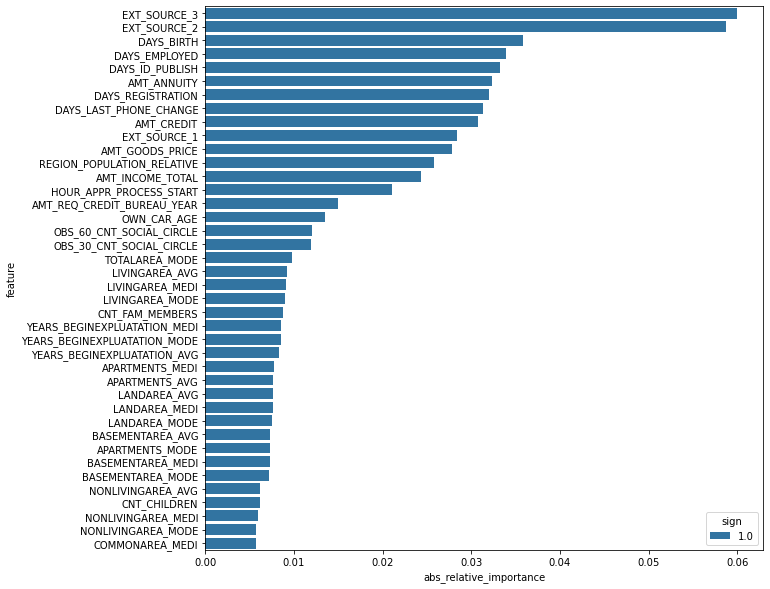

In [34]:
feature_importance['rdf_entropy'] = features_importance_rdf(rdf_entropy,features,plot = True)

In [35]:
kaggle_submit(pipeline_rdf_entropy,app_kaggle,output_name='random_forest_balanced_option.csv')

gives 0.70936

## SGD Classifier

In [36]:
sgd = SGDClassifier(class_weight='balanced',loss='modified_huber')

In [37]:
pipeline_sgd = make_pipeline(simple_imputer,scaler,sgd)

In [38]:
pipeline_sgd.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('sgdclassifier',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

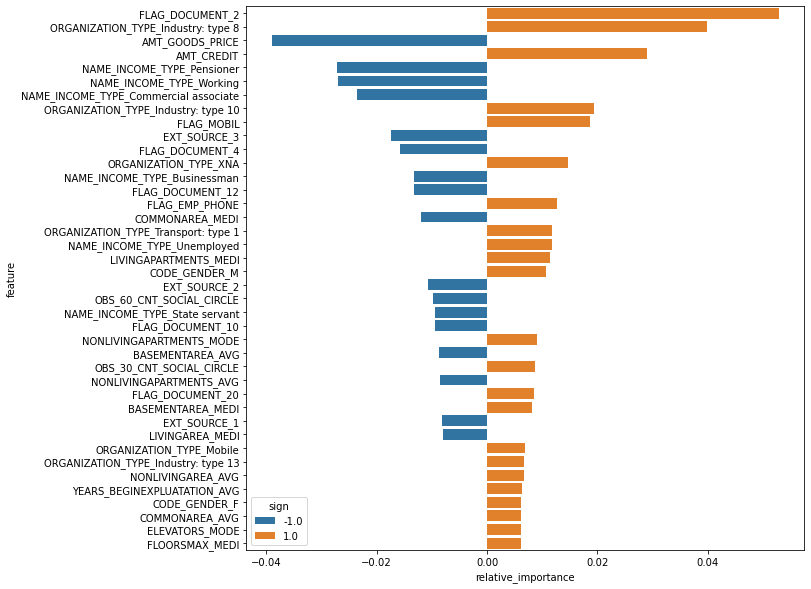

In [39]:
feature_importance['SGDClassifier'] = features_importance_lg(sgd,features,plot = True)

In [40]:
kaggle_submit(pipeline_sgd,app_kaggle,output_name='sgd_balanced_option.csv')

gives 0.696

## LGB

In [41]:
lgb = LGBMClassifier(class_weight='balanced')

In [42]:
pipeline_lgb = make_pipeline(simple_imputer,scaler,lgb)

In [43]:
pipeline_lgb.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('lgbmclassifier', LGBMClassifier(class_weight='balanced'))])

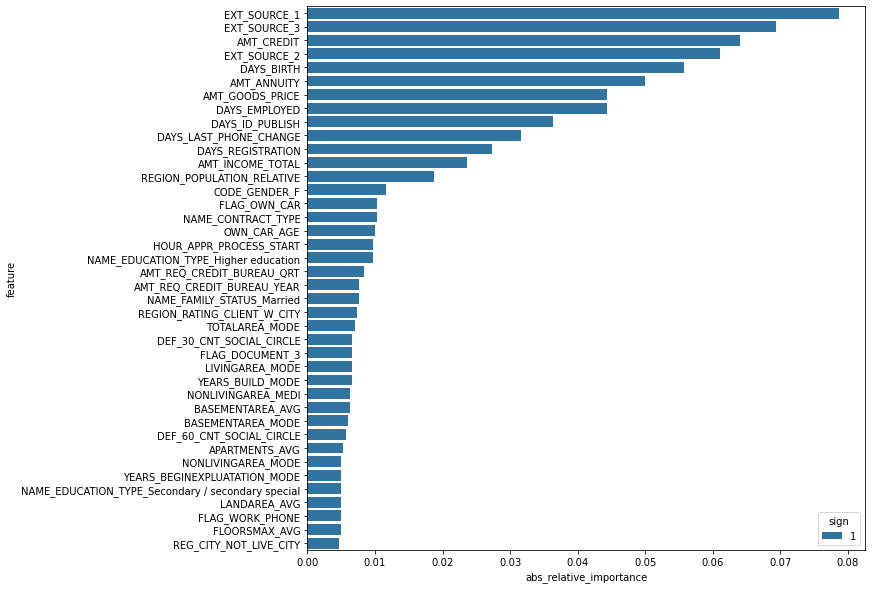

In [44]:
feature_importance['lgb'] = features_importance_rdf(lgb,features,plot = True)

In [45]:
kaggle_submit(pipeline_lgb,app_kaggle,output_name='lgb_balanced_option.csv')

kaggle gives 0.7403

## Feature importance results

In [46]:
feature_importance.keys()

dict_keys(['tree', 'lda', 'lg_bal', 'rdf_gini', 'rdf_entropy', 'SGDClassifier', 'lgb'])

In [47]:
feature_importance_results = pd.DataFrame(index = features)

In [48]:
feature_importance_results['counts']=0
feature_importance_results['rank']=0
feature_importance_results['total importance']=0
feature_importance_results['appearance in top 40']=0

In [49]:
for key in feature_importance.keys():
    n = 0
    for feature in feature_importance[key]['feature']:
        if n <= 30:
            feature_importance_results.loc[feature,'counts']+=1
        feature_importance_results.loc[feature,'rank']+=n
        feature_importance_results.loc[feature,'total importance']+= feature_importance[key].where(feature_importance[key]['feature'] == feature )['abs_relative_importance'].sum()
        n+=1
feature_importance_results['total importance'] = feature_importance_results['total importance'] / feature_importance_results['total importance'].sum()
    

In [50]:
top_40_counts_index = feature_importance_results.sort_values(by=['counts'],ascending=False).head(40).index
feature_importance_results.loc[top_40_counts_index,'appearance in top 40']+=1

top_40_importance_index = feature_importance_results.sort_values(by=['total importance'],ascending=False).head(40).index
feature_importance_results.loc[top_40_importance_index,'appearance in top 40']+=1

top_40_rank_index = feature_importance_results.sort_values(by=['rank'],ascending=True).head(40).index
feature_importance_results.loc[top_40_rank_index,'appearance in top 40']+=1

## Reducing number of feature

In [51]:
discarded_features = feature_importance_results[feature_importance_results['appearance in top 40'] == 0].index

In [52]:
selected_features = features.drop(discarded_features)
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
app_kaggle_selected = app_kaggle[selected_features]

In [56]:
np.save('data/X_train_selected',X_train_selected)
np.save('data/X_test_selected',X_test_selected)
np.save('data/app_kaggle_selected',app_kaggle_selected)

In [58]:
X_train_selected = np.load('data/X_train_selected.npy')
X_test_selected = np.load('data/X_test_selected.npy')
app_kaggle_selected = np.load('data/app_kaggle_selected.npy')

### Effect on Logistic regression

In [455]:
pipeline_lr.fit(X_train_selected,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=200))])

In [456]:
kaggle_submit(pipeline_lr,app_kaggle_selected,output_name='lr_balanced_option_selected.csv')

Kaggle gives 0.73267 was 0.73969

### Effect on SGD

In [458]:
pipeline_sgd.fit(X_train_selected,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('sgdclassifier',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

In [459]:
kaggle_submit(pipeline_sgd,app_kaggle_selected,output_name='sgd_balanced_option_selected.csv')

Kaggle gives 0.70723 was 0.62124

### Effect on Random Forest

In [460]:
pipeline_rdf_entropy.fit(X_train_selected,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy'))])

In [461]:
kaggle_submit(pipeline_rdf_entropy,app_kaggle_selected,output_name='rdf_balanced_option_selected.csv')

Kaggle gives 0.71305 was 0.71270

### Effect on LGB

In [462]:
pipeline_lgb.fit(X_train_selected,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('lgbmclassifier', LGBMClassifier(class_weight='balanced'))])

In [464]:
kaggle_submit(pipeline_lgb,app_kaggle_selected,output_name='lgb_balanced_option_selected.csv')

Kaggle gives 0.74104 was 0.74124

# Feature Engineering

## Synthetic features using PCA

In [ ]:
pca = PCA(n_components=2)
pca.fit(X_train_std)
pca.explained_variance_ratio_

In [ ]:
PC1 = pd.DataFrame(pca.components_[0],columns=['coef'])
PC1['feature'] = features
PC2 = pd.DataFrame(pca.components_[1],columns=['coef'])
PC2['feature'] = features

In [ ]:
PC1 = PC1.sort_values(by='coef',ascending=False)
PC2 = PC2.sort_values(by='coef',ascending=False)

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC1.head(30),x ='coef',y='feature')

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC2.head(30),x ='coef',y='feature')

In [ ]:
X_train_pca = pca.transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

In [ ]:
X_train_pca = np.hstack((X_train_std,X_train_pca))
X_test_pca = np.hstack((X_test_std,X_test_pca))

In [ ]:
features_pca = features.append(pd.Index(['PC1','PC2']))

In [ ]:
X_train_pca.shape

In [ ]:
lg = LogisticRegression(C=0.001,class_weight='balanced')
lg.fit(X_train_pca,y_train)

In [ ]:
A =features_importance_lg(lg,features_pca,n_features=40,plot = True)

In [ ]:
rdf.fit(X_train_pca,y_train)

In [ ]:
A = features_importance_rdf(rdf,features_pca,n_features=40,plot = True)

## Business Features

### Creating the features

In [59]:
app_data_busi = app_data.copy()
app_kaggle_busi = app_kaggle.copy()

In [60]:
app_data_busi['ANNUITY_INCOME_RATIO'] = app_data['AMT_ANNUITY']/app_data['AMT_INCOME_TOTAL']
app_kaggle_busi['ANNUITY_INCOME_RATIO'] = app_kaggle['AMT_ANNUITY']/app_kaggle['AMT_INCOME_TOTAL']

In [61]:
app_data_busi['CREDIT_INCOME_RATIO'] = app_data['AMT_CREDIT']/app_data['AMT_INCOME_TOTAL']
app_kaggle_busi['CREDIT_INCOME_RATIO'] = app_kaggle['AMT_CREDIT']/app_kaggle['AMT_INCOME_TOTAL']

In [62]:
app_data_busi['DAYS_EMPLOYED_DAYS_BIRTH_RATIO'] = app_data['DAYS_EMPLOYED']/(app_data['DAYS_BIRTH']+365*16)
app_kaggle_busi['DAYS_EMPLOYED_DAYS_BIRTH_RATIO'] = app_kaggle['DAYS_EMPLOYED']/(app_kaggle['DAYS_BIRTH']+365*16)

In [63]:
selected_features_busi = selected_features.append(pd.Index(['ANNUITY_INCOME_RATIO',
                                                   'CREDIT_INCOME_RATIO',
                                                   'DAYS_EMPLOYED_DAYS_BIRTH_RATIO']))

In [64]:
app_kaggle_busi = app_kaggle_busi[selected_features_busi]
X_busi = app_data_busi.drop( columns = ['TARGET'])[selected_features_busi]
y_busi = app_data_busi['TARGET']

In [65]:
app_kaggle_busi.shape

(48744, 62)

In [66]:
X_train_busi, X_test_busi, y_train_busi, y_test_busi = train_test_split(X_busi, y_busi, test_size=0.15, random_state=42)

### Logistic Regression

In [473]:
pipeline_lr.fit(X_train_busi,y_train_busi)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=200))])

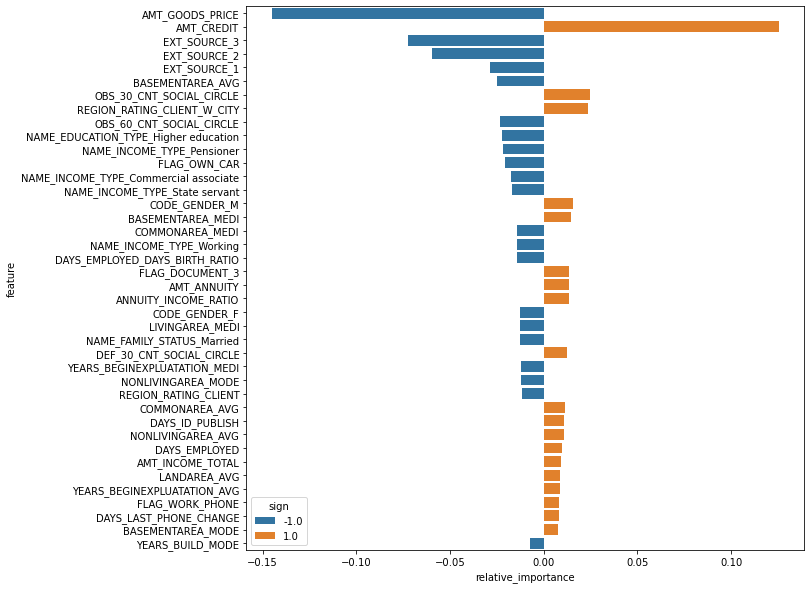

In [474]:
A = features_importance_lg(lr_bal,selected_features_busi,plot=True)

In [475]:
kaggle_submit(pipeline_lr,app_kaggle_busi,'lr_balanced_option_busi.csv')

Kaggle gives 0.73319 was 0.73267 was 0.73969

### Random Forest

In [477]:
pipeline_rdf_entropy.fit(X_train_busi,y_train_busi)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy'))])

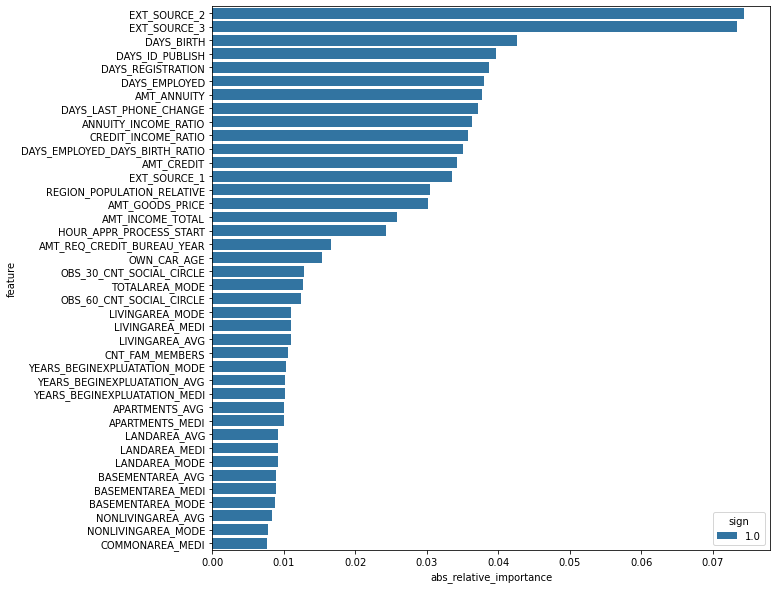

In [478]:
A = features_importance_rdf(rdf_entropy,selected_features_busi,plot=True)

In [479]:
kaggle_submit(pipeline_rdf_entropy,app_kaggle_busi,'rdf_balanced_option_busi.csv')

Kaggle gives 0.71363  was 0.71305 was 0.71270

### SGDClassifier

In [480]:
pipeline_sgd.fit(X_train_busi,y_train_busi)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('sgdclassifier',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

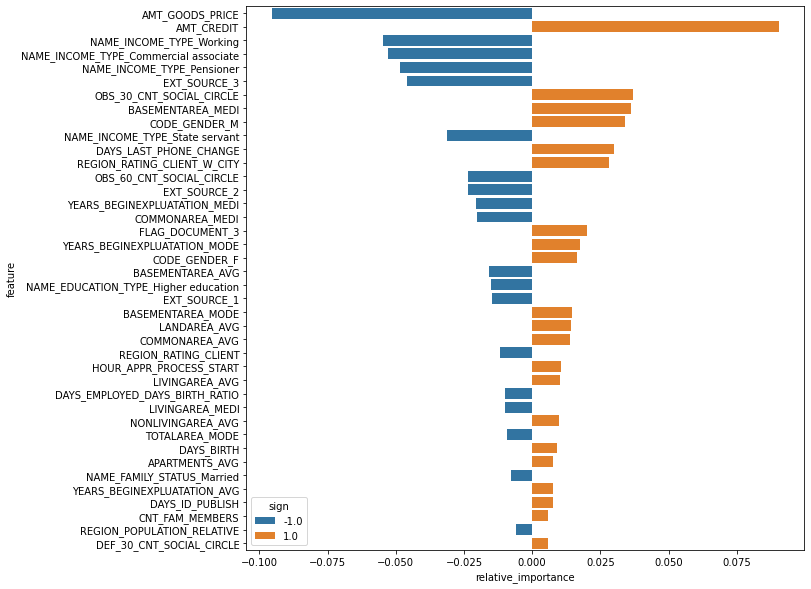

In [481]:
A = features_importance_lg(sgd,selected_features_busi,plot=True)

In [482]:
kaggle_submit(pipeline_sgd,app_kaggle_busi,'sgd_balanced_option_busi.csv')

Kaggle gives 0.69869 was 0.70723 was 0.62124

### LGB

In [483]:
pipeline_lgb.fit(X_train_busi,y_train_busi)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('lgbmclassifier', LGBMClassifier(class_weight='balanced'))])

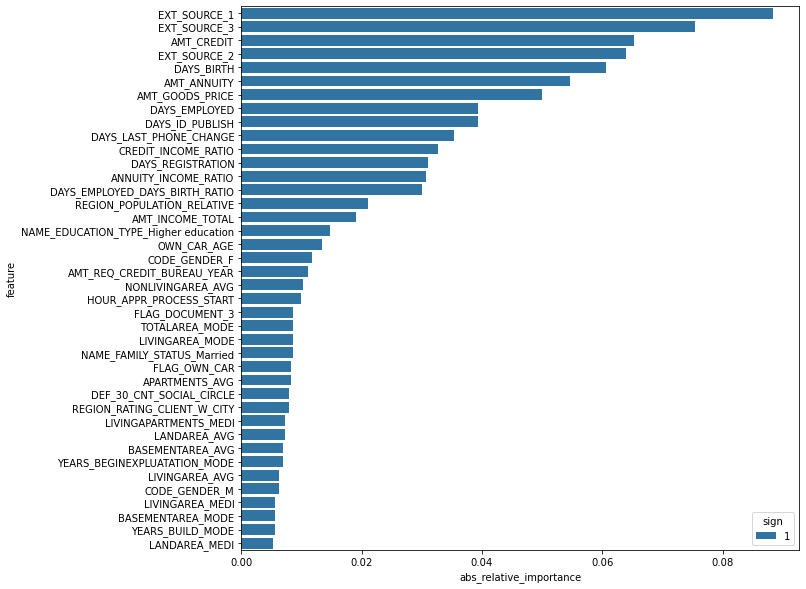

In [484]:
A = features_importance_rdf(lgb,selected_features_busi,plot=True)

In [485]:
kaggle_submit(pipeline_lgb,app_kaggle_busi,'lgb_balanced_option_busi.csv')

Kaggle gives 0.74154 was  0.74104 was 0.74124

# Model selection

## Undersampling

In [67]:
X_train_res, y_train_res = resample(X_train_busi,y_train_busi,n_samples = 100000, stratify = y_train_busi)

## Kfold cross validation

In [68]:
scores = {}

In [70]:
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=2,random_state=1)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}

In [71]:
Model_list = {'pipeline_tree':pipeline_tree,
              'pipeline_lda':pipeline_lda,
              'pipeline_lr':pipeline_lr,
              'pipeline_sgd':pipeline_sgd,
              'pipeline_rdf_entropy':pipeline_rdf_entropy,
              'pipeline_lgb':pipeline_lgb}

In [72]:
for model in Model_list:
    print(f'training {model}')
    scores[model] = cross_validate(Model_list[model],X_train_busi,y_train_busi, scoring = scoring, cv=cv)

training pipeline_tree
training pipeline_lda
training pipeline_lr
training pipeline_sgd
training pipeline_rdf_entropy
training pipeline_lgb


In [75]:
np.save('data\scores',scores)

In [93]:
scores_pd=pd.DataFrame(index=pd.Index(Model_list.keys()))

In [94]:
for model in Model_list:
    for scoring in scores[model]:
        scores_pd.loc[model,scoring]=scores[model][scoring].mean()
    

In [95]:
scores_pd

,fit_time,score_time,test_ROC AUC,test_F1,test_Accuracy,test_Precision,test_Recall
pipeline_tree,13.745882,0.321956,0.538518,0.151778,0.859326,0.147843,0.155961
pipeline_lda,5.562783,0.416827,0.742799,0.039405,0.918969,0.456366,0.020597
pipeline_lr,7.228813,0.363874,0.743566,0.256933,0.685832,0.158774,0.673003
pipeline_sgd,7.478756,0.280855,0.679801,0.216647,0.622889,0.130660,0.642095
pipeline_rdf_entropy,121.630816,4.086249,0.724854,0.006645,0.919369,0.588130,0.003342
pipeline_lgb,9.007375,0.755830,0.754696,0.268194,0.706291,0.167850,0.666864


# Tuning the selected model

### Hyperparameter tuning

In [ ]:
# Parameter grid
param_grid = {'C': [0.01,0.1,1]}

# score to optimize
score = 'roc_auc'

# Creating a classifier with GridSearch optimization on hyparameter C
clf = GridSearchCV(
    LogisticRegression(max_iter=200), # classifier
    param_grid,     # hyperparameter C
    cv=5,           # number of fold for cross validation
    scoring=score,   # score à optimiser
    n_jobs=-1,
)

# Fit on training dataset
clf.fit(X_train_scaled, y_train)

# Show best hyperparameters
print("Best parameters on training dataset:")
print(clf.best_params_)

# Show performance
print("Cross validation results :")
for mean, std, params in zip(
        clf.cv_results_['mean_test_score'], # score moyen
        clf.cv_results_['std_test_score'],  # écart-type du score
        clf.cv_results_['params']           # valeur de l'hyperparamètre
    ):

    print("{} = {:.3f} (+/-{:.03f}) for {}".format(
        score,
        mean,
        std*2,
        params
    ) )

In [ ]:
lg = LogisticRegression(C=0.0005)

In [ ]:
lg.fit(X_train_scaled,y_train)

In [ ]:
log_reg_pred = lg.predict_proba(X_test_scaled)[:,1]

In [ ]:
log_reg_pred.shape

In [ ]:
roc_auc_score(y_test,log_reg_pred)

#### Submitting to kaggle

In [ ]:
def kaggle_submit(estimator,data,output_name = 'submission_default.csv'):
    kaggle_pred = estimator.predict(data)
    kaggle_df = pd.DataFrame(data['SK_ID_CURR'],columns=['SK_ID_CURR'])
    kaggle_df['TARGET'] = kaggle_pred
    kaggle_df.to_csv('data/'+output_name,index = False)

In [68]:
# Class Unbalance

In [ ]:
plt.hist(y_train)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count')
plt.show()

In [ ]:
## Class unbalanced strategy

In [ ]:
### Over sampling

In [ ]:
X_up,y_up = resample(X_train_std[y_train == 1],
                     y_train[y_train == 1],
                     replace=True,
                     n_samples=X_train_std[y_train == 0].shape[0])

X_train_up = np.vstack((X_train_std[y_train == 0], X_up))
y_train_up = np.hstack((y_train[y_train == 0], y_up))

plt.hist(y_train_up)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count with resampling')
plt.show()

In [ ]:
### Data augmentation Using SMOTE

In [ ]:
oversample = imblearn.over_sampling.SMOTE(sampling_strategy = 0.4)
undersample = imblearn.under_sampling.RandomUnderSampler(sampling_strategy = 0.7)

pipeline_smote = imblearn.pipeline.Pipeline(steps = [('over',oversample),('under',undersample)])

X_train_smote,y_train_smote = pipeline_smote.fit_resample(X_train_std,y_train)

plt.hist(y_train_smote)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count with SMOTE')
plt.show()